### **Multi Linear Regression**

In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
california = fetch_california_housing()

In [5]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [8]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [10]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [11]:
california.target_names

['MedHouseVal']

In [12]:
print(california.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [14]:
print(california.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [15]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [16]:
## lets prepare the DataFrame
df=pd.DataFrame(california.data,columns=california.feature_names)

In [17]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [19]:
df['Price']=california.target

In [20]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [22]:
df.info

<bound method DataFrame.info of        MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  Price
0      8.3252      41.0  6.984127  ...     37.88    -122.23  4.526
1      8.3014      21.0  6.238137  ...     37.86    -122.22  3.585
2      7.2574      52.0  8.288136  ...     37.85    -122.24  3.521
3      5.6431      52.0  5.817352  ...     37.85    -122.25  3.413
4      3.8462      52.0  6.281853  ...     37.85    -122.25  3.422
...       ...       ...       ...  ...       ...        ...    ...
20635  1.5603      25.0  5.045455  ...     39.48    -121.09  0.781
20636  2.5568      18.0  6.114035  ...     39.49    -121.21  0.771
20637  1.7000      17.0  5.205543  ...     39.43    -121.22  0.923
20638  1.8672      18.0  5.329513  ...     39.43    -121.32  0.847
20639  2.3886      16.0  5.254717  ...     39.37    -121.24  0.894

[20640 rows x 9 columns]>

In [23]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [25]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [26]:
df.corr

<bound method DataFrame.corr of        MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  Price
0      8.3252      41.0  6.984127  ...     37.88    -122.23  4.526
1      8.3014      21.0  6.238137  ...     37.86    -122.22  3.585
2      7.2574      52.0  8.288136  ...     37.85    -122.24  3.521
3      5.6431      52.0  5.817352  ...     37.85    -122.25  3.413
4      3.8462      52.0  6.281853  ...     37.85    -122.25  3.422
...       ...       ...       ...  ...       ...        ...    ...
20635  1.5603      25.0  5.045455  ...     39.48    -121.09  0.781
20636  2.5568      18.0  6.114035  ...     39.49    -121.21  0.771
20637  1.7000      17.0  5.205543  ...     39.43    -121.22  0.923
20638  1.8672      18.0  5.329513  ...     39.43    -121.32  0.847
20639  2.3886      16.0  5.254717  ...     39.37    -121.24  0.894

[20640 rows x 9 columns]>

<Axes: >

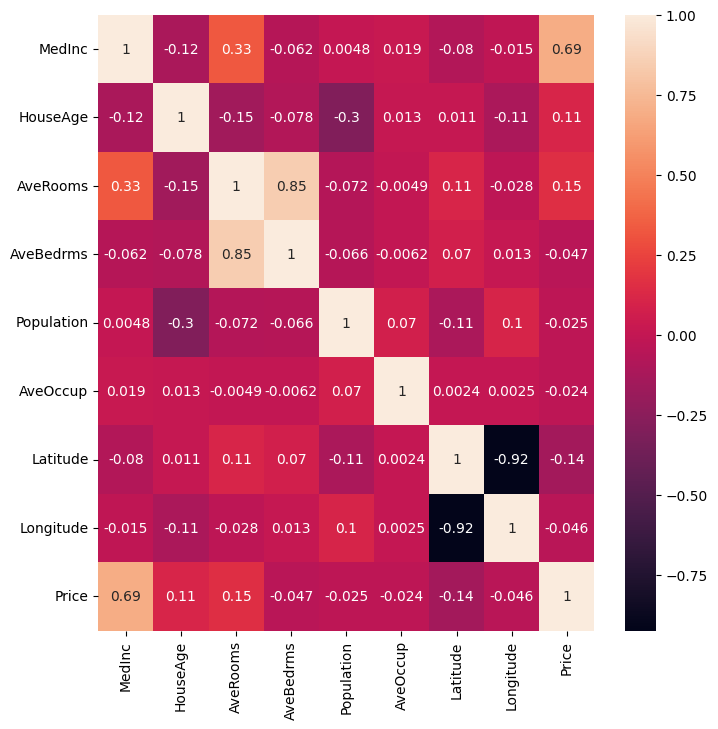

In [37]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True)


In [40]:
#Independent and dependent feature

X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [42]:
# train test split 

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=10)

In [45]:
X_train.shape,y_train.shape

((13828, 8), (13828,))

In [46]:
#standardize

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [47]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [49]:
#Model Training

from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [50]:
regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
regression.coef_

array([ 0.82872299,  0.1231163 , -0.27068752,  0.32859106,  0.00213572,
       -0.02810091, -0.93017985, -0.89505497])

In [53]:
regression.intercept_

np.float64(2.0634768086491158)

In [54]:
#prediction
y_pred=regression.predict(X_test)

In [55]:
y_pred

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012], shape=(6812,))

In [59]:
#performance metrics

from sklearn.metrics import mean_squared_error,mean_absolute_error
print('MSE =',mean_squared_error(y_test,y_pred))
print('MAE =',mean_absolute_error(y_test,y_pred))
print('RMSE =',np.sqrt(mean_squared_error(y_test,y_pred)))

MSE = 0.5522332399363619
MAE = 0.537105694300796
RMSE = 0.7431239734636219


In [60]:
#rsquared and adjusted rsquared

from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R squared =",score)

R squared = 0.593595852643664


In [61]:
#adjusted rsquared

1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.5931179409607519

### **Assumptions**

Text(0, 0.5, 'predicted')

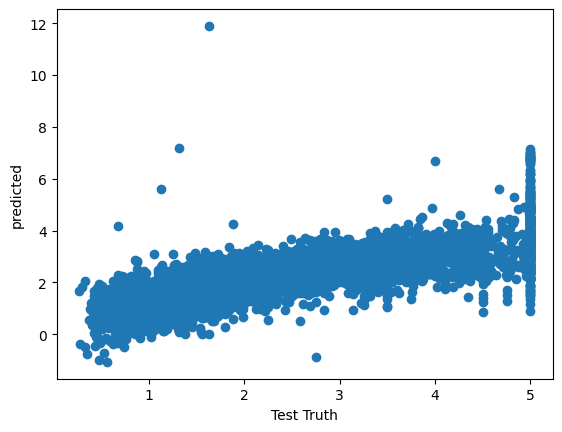

In [63]:
plt.scatter(y_test,y_pred)
plt.xlabel('Test Truth')
plt.ylabel('predicted')

In [64]:
residuals=y_test-y_pred

In [65]:
residuals

20303   -1.329975
16966    0.960885
10623   -0.746908
6146    -0.307462
2208    -0.662167
           ...   
13490   -0.243475
9340     0.507182
17439   -1.366037
2602     0.046480
7180    -0.627770
Name: Price, Length: 6812, dtype: float64

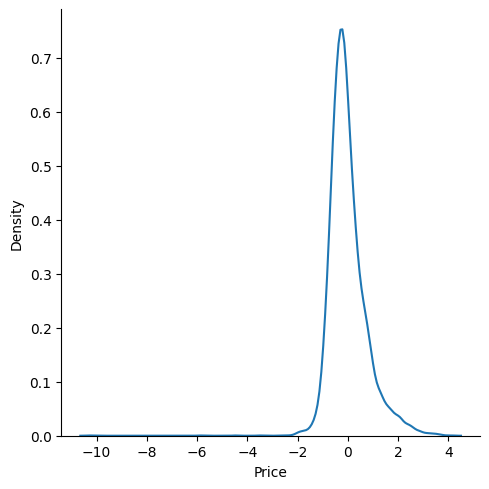

In [67]:
sns.displot(residuals,kind='kde')

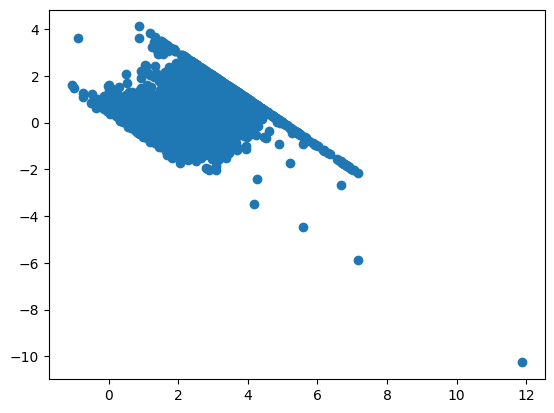

In [69]:
plt.scatter(y_pred,residuals)
#we can see a linearity and non uniform distribution so the accuracy of the model is not great 

### **Pickling***

Python pickle model is used for serialising and de-serialising a python object structure any object in python can be pickeled so that it can be saved on the disk.what pickle does that it serailises the object first before writting it to file.Pickling is a way of converting a python object (list,dict,etc) into a character stream the idea is that this character stream contains all the information necessary to reconstruct the object in another python script 

In [ ]:
import pickle
pickle.dump(regression,open("regresison.pkl","wb"))#write byte

In [72]:
#loading from a pickle
model=pickle.load(open('regresison.pkl','rb'))#read byte

In [73]:
model.predict(X_test)

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012], shape=(6812,))